In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data=pd.read_csv("/content/child_education_risk_intelligence.csv")
data

,student_id,record_generated_date,enrollment_date,academic_year,country,state_province,location_type,age,gender,grade_level,...,early_marriage_risk_flag,community_conflict_zone,seasonal_migration_family,ngo_intervention_present,literacy_program_enrolled,language_barrier_flag,report_source,case_notes,dropout_probability_score,dropout_risk_level
0,STU-0000001,2026-03-10,2023-10-10,2021-2022,Kenya,Turkana,Urban,16,Female,11,...,False,False,False,False,False,False,NGO Field Worker,Student shows strong academic performance desp...,0.2858,Low
1,STU-0000002,2019-05-26,2018-10-28,2022-2023,Ethiopia,Oromia,Rural,6,Male,1,...,False,False,False,False,False,False,Government Survey,Household relocated; enrollment continuity at ...,0.8148,Medium
2,STU-0000003,2021-04-17,2020-04-02,2024-2025,Pakistan,Balochistan,Rural,10,Male,6,...,False,False,False,False,False,False,School Record,Family relies on child's income during harvest...,0.8617,Medium
3,STU-0000004,2023-04-29,2021-06-21,2023-2024,Nigeria,Sokoto,Urban,14,Female,9,...,False,False,False,False,False,False,NGO Field Worker,NGO field worker recommends scholarship support.,0.8831,Medium
4,STU-0000005,2024-05-31,2022-12-04,2021-2022,India,Uttar Pradesh,Rural,13,Female,7,...,False,False,False,False,False,False,Community Volunteer,Teacher reports improved engagement after coun...,0.9692,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,STU-0199996,2021-01-01,2020-03-14,2023-2024,Nigeria,Kano,Semi-Urban,10,Male,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.3299,Low
199996,STU-0199997,2024-10-14,2023-09-20,2021-2022,Nigeria,Kaduna,Rural,9,Female,3,...,False,False,False,False,False,False,Mobile Data Collection App,Teacher reports improved engagement after coun...,0.6820,Medium
199997,STU-0199998,2024-05-20,2022-08-05,2024-2025,India,Bihar,Semi-Urban,8,Female,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.9230,High
199998,STU-0199999,2019-11-27,2019-04-07,2024-2025,Pakistan,Sindh,Urban,11,Female,7,...,True,False,False,False,False,False,Government Survey,Long commute distance cited as barrier to regu...,0.9465,High


In [7]:
data.info()
data.isnull().sum()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   student_id                     200000 non-null  object 
 1   record_generated_date          200000 non-null  object 
 2   enrollment_date                200000 non-null  object 
 3   academic_year                  200000 non-null  object 
 4   country                        200000 non-null  object 
 5   state_province                 200000 non-null  object 
 6   location_type                  200000 non-null  object 
 7   age                            200000 non-null  int64  
 8   gender                         200000 non-null  object 
 9   grade_level                    200000 non-null  int64  
 10  school_type                    200000 non-null  object 
 11  distance_to_school_km          191861 non-null  float64
 12  mode_of_transport             

(200000, 47)

In [9]:
data=data.drop_duplicates(subset="student_id")
data

,student_id,record_generated_date,enrollment_date,academic_year,country,state_province,location_type,age,gender,grade_level,...,early_marriage_risk_flag,community_conflict_zone,seasonal_migration_family,ngo_intervention_present,literacy_program_enrolled,language_barrier_flag,report_source,case_notes,dropout_probability_score,dropout_risk_level
0,STU-0000001,2026-03-10,2023-10-10,2021-2022,Kenya,Turkana,Urban,16,Female,11,...,False,False,False,False,False,False,NGO Field Worker,Student shows strong academic performance desp...,0.2858,Low
1,STU-0000002,2019-05-26,2018-10-28,2022-2023,Ethiopia,Oromia,Rural,6,Male,1,...,False,False,False,False,False,False,Government Survey,Household relocated; enrollment continuity at ...,0.8148,Medium
2,STU-0000003,2021-04-17,2020-04-02,2024-2025,Pakistan,Balochistan,Rural,10,Male,6,...,False,False,False,False,False,False,School Record,Family relies on child's income during harvest...,0.8617,Medium
3,STU-0000004,2023-04-29,2021-06-21,2023-2024,Nigeria,Sokoto,Urban,14,Female,9,...,False,False,False,False,False,False,NGO Field Worker,NGO field worker recommends scholarship support.,0.8831,Medium
4,STU-0000005,2024-05-31,2022-12-04,2021-2022,India,Uttar Pradesh,Rural,13,Female,7,...,False,False,False,False,False,False,Community Volunteer,Teacher reports improved engagement after coun...,0.9692,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,STU-0199996,2021-01-01,2020-03-14,2023-2024,Nigeria,Kano,Semi-Urban,10,Male,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.3299,Low
199996,STU-0199997,2024-10-14,2023-09-20,2021-2022,Nigeria,Kaduna,Rural,9,Female,3,...,False,False,False,False,False,False,Mobile Data Collection App,Teacher reports improved engagement after coun...,0.6820,Medium
199997,STU-0199998,2024-05-20,2022-08-05,2024-2025,India,Bihar,Semi-Urban,8,Female,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.9230,High
199998,STU-0199999,2019-11-27,2019-04-07,2024-2025,Pakistan,Sindh,Urban,11,Female,7,...,True,False,False,False,False,False,Government Survey,Long commute distance cited as barrier to regu...,0.9465,High


In [10]:
data['record_generated_date']=pd.to_datetime(data['record_generated_date'],errors='coerce')
data['enrollment_date']=pd.to_datetime(data['enrollment_date'],errors='coerce')
data

,student_id,record_generated_date,enrollment_date,academic_year,country,state_province,location_type,age,gender,grade_level,...,early_marriage_risk_flag,community_conflict_zone,seasonal_migration_family,ngo_intervention_present,literacy_program_enrolled,language_barrier_flag,report_source,case_notes,dropout_probability_score,dropout_risk_level
0,STU-0000001,2026-03-10,2023-10-10,2021-2022,Kenya,Turkana,Urban,16,Female,11,...,False,False,False,False,False,False,NGO Field Worker,Student shows strong academic performance desp...,0.2858,Low
1,STU-0000002,2019-05-26,2018-10-28,2022-2023,Ethiopia,Oromia,Rural,6,Male,1,...,False,False,False,False,False,False,Government Survey,Household relocated; enrollment continuity at ...,0.8148,Medium
2,STU-0000003,2021-04-17,2020-04-02,2024-2025,Pakistan,Balochistan,Rural,10,Male,6,...,False,False,False,False,False,False,School Record,Family relies on child's income during harvest...,0.8617,Medium
3,STU-0000004,2023-04-29,2021-06-21,2023-2024,Nigeria,Sokoto,Urban,14,Female,9,...,False,False,False,False,False,False,NGO Field Worker,NGO field worker recommends scholarship support.,0.8831,Medium
4,STU-0000005,2024-05-31,2022-12-04,2021-2022,India,Uttar Pradesh,Rural,13,Female,7,...,False,False,False,False,False,False,Community Volunteer,Teacher reports improved engagement after coun...,0.9692,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,STU-0199996,2021-01-01,2020-03-14,2023-2024,Nigeria,Kano,Semi-Urban,10,Male,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.3299,Low
199996,STU-0199997,2024-10-14,2023-09-20,2021-2022,Nigeria,Kaduna,Rural,9,Female,3,...,False,False,False,False,False,False,Mobile Data Collection App,Teacher reports improved engagement after coun...,0.6820,Medium
199997,STU-0199998,2024-05-20,2022-08-05,2024-2025,India,Bihar,Semi-Urban,8,Female,5,...,False,False,False,False,False,False,School Record,NGO field worker recommends scholarship support.,0.9230,High
199998,STU-0199999,2019-11-27,2019-04-07,2024-2025,Pakistan,Sindh,Urban,11,Female,7,...,True,False,False,False,False,False,Government Survey,Long commute distance cited as barrier to regu...,0.9465,High


In [11]:
text_cols = data.select_dtypes(include="object").columns

for col in text_cols:
    data[col] = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )


In [12]:
from sklearn.impute import SimpleImputer
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
median_imputer = SimpleImputer(strategy='median')
data[num_cols] = median_imputer.fit_transform(data[num_cols])

In [13]:
data['case_notes'] = data['case_notes'].fillna("No Remarks")
data['case_notes'].isnull().sum()

np.int64(0)

In [14]:
cat = data.select_dtypes(include=['object']).columns.drop("case_notes")
mode = SimpleImputer(strategy="most_frequent")
data[cat] = mode.fit_transform(data[cat])

In [15]:
print(data[data["attendance_rate_pct"]<0])
print(data[data["household_income_monthly_usd"]<0])

Empty DataFrame
Columns: [student_id, record_generated_date, enrollment_date, academic_year, country, state_province, location_type, age, gender, grade_level, school_type, distance_to_school_km, mode_of_transport, household_income_monthly_usd, mother_education_level, father_education_level, family_size, number_of_siblings, is_orphan, single_parent_household, household_has_electricity, household_has_internet_access, owns_smartphone_or_computer, child_labor_involvement, attendance_rate_pct, average_test_score_pct, previous_year_pass, number_of_school_transfers, disciplinary_incidents_count, bullying_incidents_reported, health_issues_reported, special_needs_status, free_meal_program_enrolled, scholarship_received, extracurricular_participation, teacher_student_ratio, school_infrastructure_score, early_marriage_risk_flag, community_conflict_zone, seasonal_migration_family, ngo_intervention_present, literacy_program_enrolled, language_barrier_flag, report_source, case_notes, dropout_probabi

In [16]:
numeric_C=data.select_dtypes(include=np.number).columns

outlier_cols = [
    "attendance_rate_pct",
    "household_income_monthly_usd"
]

for col in outlier_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

print(data.shape)

(188318, 47)


In [17]:
binary = [
    'household_has_internet_access',
    'receives_midday',
    'has_disability',
    'parental_support'
]

binary_mapping = {
    "Yes": 1,
    "No": 0,
    "Y": 1,
    "N": 0,
    "True": 1,
    "False": 0,
    True: 1,
    False: 0
}

for col in binary:
    if col in data.columns:
        data[col] = data[col].replace(binary_mapping)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = data.select_dtypes(include="object").columns

for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print("Label Encoding Completed")

Label Encoding Completed


In [19]:
X = data.drop("dropout_risk_level", axis=1)
y = data["dropout_risk_level"].astype(int)

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (188318, 46)
Target Shape : (188318,)


In [20]:
date_cols = ["record_generated_date", "enrollment_date"]

X = X.drop(
    columns=[col for col in date_cols if col in X.columns]
)

print("Date columns removed.")

Date columns removed.


/tmp/ipykernel_514/2752472580.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


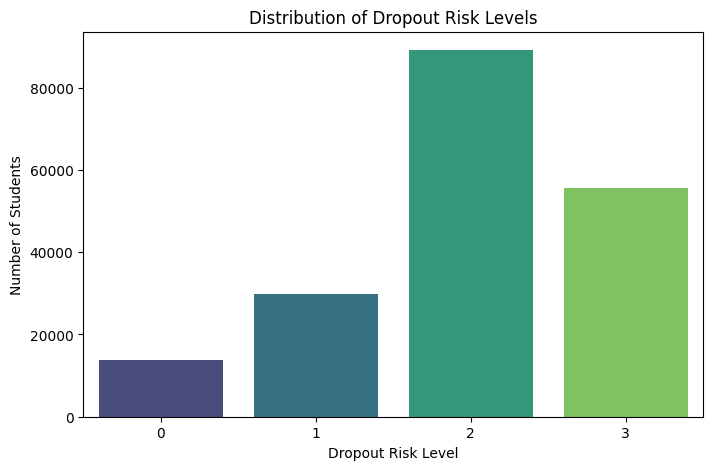

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="dropout_risk_level",
    data=data,
    palette="viridis"
)

plt.title("Distribution of Dropout Risk Levels")
plt.xlabel("Dropout Risk Level")
plt.ylabel("Number of Students")

plt.show()

/tmp/ipykernel_514/3325597744.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


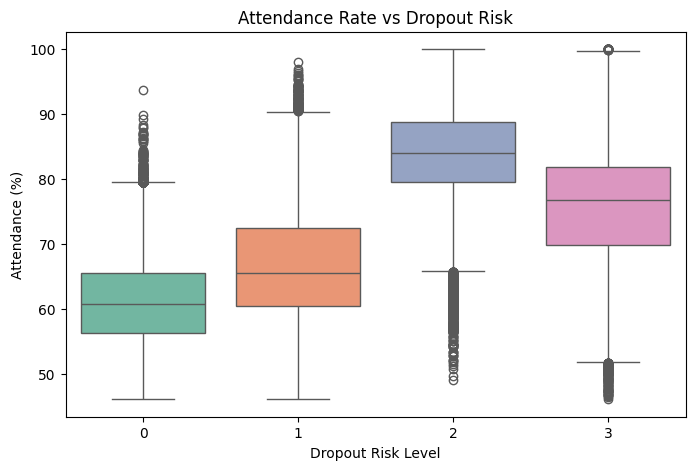

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="dropout_risk_level",
    y="attendance_rate_pct",
    data=data,
    palette="Set2"
)

plt.title("Attendance Rate vs Dropout Risk")
plt.xlabel("Dropout Risk Level")
plt.ylabel("Attendance (%)")

plt.show()

/tmp/ipykernel_514/961330200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


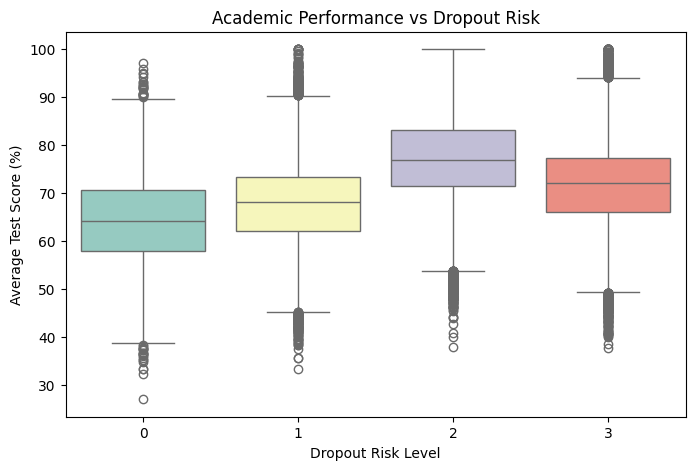

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="dropout_risk_level",
    y="average_test_score_pct",
    data=data,
    palette="Set3"
)

plt.title("Academic Performance vs Dropout Risk")
plt.xlabel("Dropout Risk Level")
plt.ylabel("Average Test Score (%)")

plt.show()

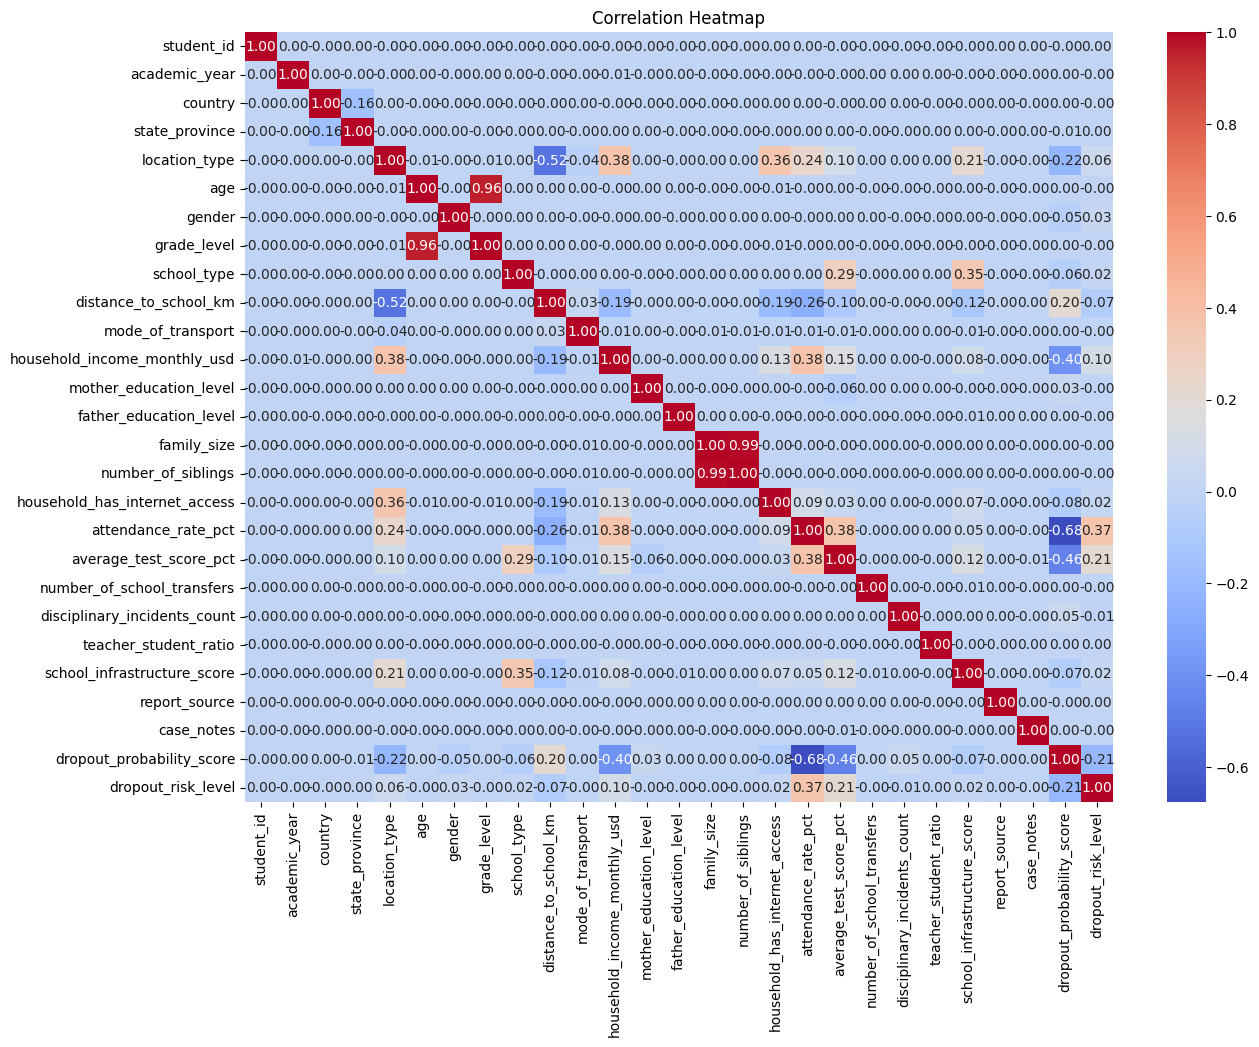

In [48]:
import numpy as np

plt.figure(figsize=(14,10))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

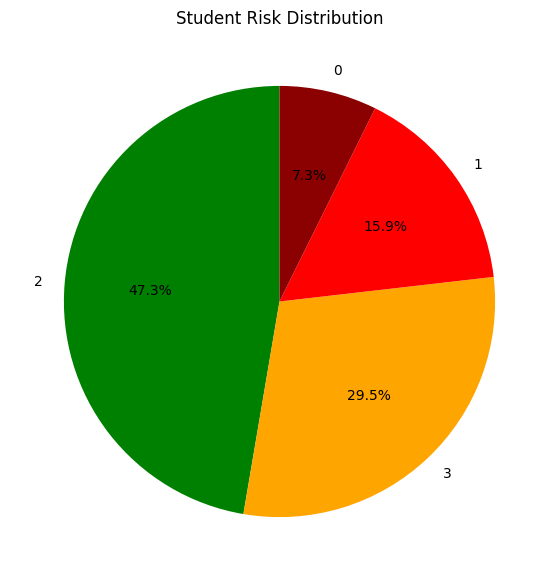

In [51]:
risk = data["dropout_risk_level"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk,
    labels=risk.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["green","orange","red","darkred"]
)

plt.title("Student Risk Distribution")

plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (150654, 44)
Testing Shape : (37664, 44)


In [22]:
print("Before SMOTE")

print(y_train.value_counts())

print()

print((y_train.value_counts(normalize=True)*100).round(2))

Before SMOTE
dropout_risk_level
2    71293
3    44441
1    23900
0    11020
Name: count, dtype: int64

dropout_risk_level
2    47.32
3    29.50
1    15.86
0     7.31
Name: proportion, dtype: float64


In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")

print(y_train.value_counts())

After SMOTE
dropout_risk_level
2    71293
3    71293
0    71293
1    71293
Name: count, dtype: int64


In [41]:
print(y.value_counts(normalize=True) * 100)

dropout_risk_level
2    47.322083
3    29.499039
1    15.864123
0     7.314755
Name: proportion, dtype: float64


In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train_encoded
)

print(X_train.shape)
print(X_train_smote.shape)

(150654, 19)
(285172, 19)


In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(encoder.classes_),
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train_smote, y_train_smote)

pred = xgb.predict(X_test)

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 500],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=len(encoder.classes_),
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=params,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_smote, y_train_smote)

print(search.best_params_)
print(search.best_score_)

{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
0.7085552252749385


In [55]:
from xgboost import XGBClassifier

best_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(encoder.classes_),
    subsample=0.9,
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=1.0,
    eval_metric="mlogloss",
    random_state=42
)

best_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

In [56]:
pred = best_model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_encoded, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test_encoded, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.6415940951571792

Classification Report

              precision    recall  f1-score   support

           0       0.53      0.47      0.50      2755
           1       0.47      0.45      0.46      5975
           2       0.78      0.83      0.80     17823
           3       0.51      0.48      0.49     11111

    accuracy                           0.64     37664
   macro avg       0.57      0.56      0.57     37664
weighted avg       0.63      0.64      0.64     37664


Confusion Matrix

[[ 1306  1109    35   305]
 [  911  2712   372  1980]
 [   17   169 14858  2779]
 [  217  1722  3883  5289]]


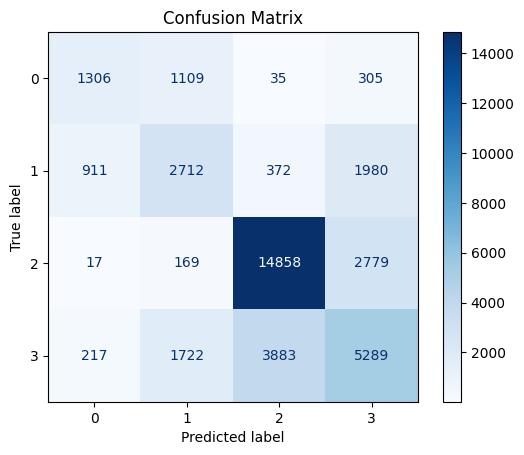

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [62]:
import joblib

joblib.dump(best_model, "guardian_ai_xgboost.pkl")

['guardian_ai_xgboost.pkl']

In [63]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.5 MB/s eta 0:00:00


In [66]:
%%writefile gaurdianAi.Py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Guardian AI",
    page_icon="🎓",
    layout="wide"
)

model = joblib.load("guardian_ai_xgboost.pkl")

st.title("🎓 Guardian AI")
st.subheader("Student Dropout Risk Prediction System")

st.markdown("---")

col1, col2 = st.columns(2)

with col1:
    age = st.number_input("Age", 5, 25, 15)
    gender = st.selectbox("Gender", ["Male", "Female"])
    attendance_rate_pct = st.slider("Attendance (%)", 0.0, 100.0, 80.0)
    average_test_score_pct = st.slider("Average Test Score (%)", 0.0, 100.0, 70.0)
    household_income_monthly_usd = st.number_input("Monthly Household Income", 0.0, 100000.0, 5000.0)
    parental_support = st.selectbox("Parental Support", ["Yes", "No"])
    household_has_internet_access = st.selectbox("Internet Access", ["Yes", "No"])

with col2:
    receives_midday = st.selectbox("Receives Midday Meal", ["Yes", "No"])
    has_disability = st.selectbox("Disability", ["Yes", "No"])
    study_hours_per_day = st.number_input("Study Hours Per Day", 0.0, 15.0, 2.0)
    extracurricular_participation = st.selectbox("Extracurricular Participation", ["Yes", "No"])
    parent_education_level = st.selectbox(
        "Parent Education",
        ["Primary", "Secondary", "Higher Secondary", "Graduate", "Postgraduate"]
    )
    school_type = st.selectbox(
        "School Type",
        ["Government", "Private", "Aided"]
    )
    location = st.selectbox(
        "Location",
        ["Urban", "Semi-Urban", "Rural"]
    )

gender = 1 if gender == "Male" else 0

yes_no = {
    "Yes": 1,
    "No": 0
}

parent_map = {
    "Primary":0,
    "Secondary":1,
    "Higher Secondary":2,
    "Graduate":3,
    "Postgraduate":4
}

school_map = {
    "Government":0,
    "Private":1,
    "Aided":2
}

location_map = {
    "Urban":0,
    "Semi-Urban":1,
    "Rural":2
}

if st.button("Predict Risk Level", use_container_width=True):

    input_data = pd.DataFrame([{
        "age": age,
        "gender": gender,
        "attendance_rate_pct": attendance_rate_pct,
        "average_test_score_pct": average_test_score_pct,
        "household_income_monthly_usd": household_income_monthly_usd,
        "parental_support": yes_no[parental_support],
        "household_has_internet_access": yes_no[household_has_internet_access],
        "receives_midday": yes_no[receives_midday],
        "has_disability": yes_no[has_disability],
        "study_hours_per_day": study_hours_per_day,
        "extracurricular_participation": yes_no[extracurricular_participation],
        "parent_education_level": parent_map[parent_education_level],
        "school_type": school_map[school_type],
        "location": location_map[location]
    }])

    prediction = model.predict(input_data)[0]

    st.markdown("---")

    if prediction == 0:
        st.success("🟢 Low Dropout Risk")
        st.info("""
        **Recommendations**
        - Continue regular monitoring.
        - Encourage extracurricular activities.
        - Maintain attendance above 90%.
        """)

    elif prediction == 1:
        st.warning("🟡 Medium Dropout Risk")
        st.info("""
        **Recommendations**
        - Improve attendance.
        - Provide academic mentoring.
        - Increase parental involvement.
        """)

    elif prediction == 2:
        st.error("🟠 High Dropout Risk")
        st.info("""
        **Recommendations**
        - Immediate counselling.
        - Weekly academic monitoring.
        - Financial assistance if required.
        """)

    else:
        st.error("🔴 Critical Dropout Risk")
        st.info("""
        **Recommendations**
        - Emergency intervention.
        - Assign dedicated mentor.
        - Home visit and counselling.
        - Continuous performance monitoring.
        """)

Writing gaurdianAi.Py


In [ ]:
!streamlit run gaurdianAi.py &> /content/logs.txt & curl ipv4 icanhazip.com
!npx localtunnel --port 8501

curl: (6) Could not resolve host: ipv4
136.110.27.50
⠙⠹⠸⠼your url is: https://fluffy-icons-cross.loca.lt
